In [1]:
# [AUDIT-SEED] Reproducibility seeds
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except ImportError:
    pass


# Hybrid 2: Autoencoder + XGBoost for Credit Card Fraud Detection

**Approach:** Train an autoencoder on **normal transactions only** to learn the pattern of legitimate spending. The reconstruction error becomes a new feature — fraudulent transactions should have higher reconstruction error because they deviate from normal patterns. This error feature is then combined with the original engineered features and fed into XGBoost.

**Pipeline:**
1. Load engineered datasets
2. Train autoencoder on normal transactions only
3. Compute reconstruction error for all transactions
4. Merge reconstruction error as a new feature
5. Train XGBoost with class weights (baseline)
6. Train XGBoost with SMOTE
7. Train XGBoost with SMOTE + hyperparameter tuning
8. Evaluation and comparison

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, precision_recall_curve, auc, roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cpu
Device: cpu


## 1. Load Engineered Datasets

In [3]:
# Load engineered datasets
train_df = pd.read_csv('../data/engineered/fraudTrain_engineered.csv')
test_df = pd.read_csv('../data/engineered/fraudTest_engineered.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nFraud rate (train): {train_df['is_fraud'].mean():.4f} ({train_df['is_fraud'].sum()} frauds)")
print(f"Fraud rate (test): {test_df['is_fraud'].mean():.4f} ({test_df['is_fraud'].sum()} frauds)")

# Define features — drop unix_time and target
drop_cols = ['is_fraud', 'unix_time']
feature_cols = [c for c in train_df.columns if c not in drop_cols]
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")

X_train = train_df[feature_cols].values
y_train = train_df['is_fraud'].values
X_test = test_df[feature_cols].values
y_test = test_df['is_fraud'].values

Train shape: (1296675, 16)
Test shape: (555719, 16)

Fraud rate (train): 0.0058 (7506 frauds)
Fraud rate (test): 0.0039 (2145 frauds)

Features (14): ['amt', 'city_pop', 'hour', 'month', 'distance_cardholder_merchant', 'age', 'is_weekend', 'is_night', 'velocity_1h', 'velocity_24h', 'amount_velocity_1h', 'category_encoded', 'gender_encoded', 'day_of_week_encoded']


In [4]:
# Scale features for autoencoder
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Split training data: normal transactions only for autoencoder training
X_train_normal = X_train_scaled[y_train == 0]
print(f"Normal transactions for AE training: {X_train_normal.shape[0]:,}")
print(f"Fraud transactions (excluded from AE training): {(y_train == 1).sum():,}")

Normal transactions for AE training: 1,289,169
Fraud transactions (excluded from AE training): 7,506


## 1b. XGBoost-Only Baselines (No Autoencoder)

Train XGBoost using only the 14 original engineered features — no reconstruction error. This establishes the baseline that the autoencoder must beat.

In [5]:
import os
# === XGBoost-Only Baselines (14 features, no autoencoder) ===
import joblib
from sklearn.metrics import classification_report, f1_score, roc_auc_score, average_precision_score

# Load saved baseline XGBoost
baseline_path = os.path.join('..', 'models', 'saved', '01_baseline', 'xgboost_smote_tuned.joblib')
xgb_baseline = joblib.load(baseline_path)
print(f'Loaded baseline XGBoost from: {baseline_path}')

# Evaluate baseline on test set (no AE features)
y_pred_base = xgb_baseline.predict(X_test)
y_proba_base = xgb_baseline.predict_proba(X_test)[:, 1]

print('\n' + '='*50)
print('BASELINE: XGBoost (no autoencoder features)')
print('='*50)
print(f'F1 Score:  {f1_score(y_test, y_pred_base):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba_base):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, y_proba_base):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=['Legit', 'Fraud']))


Loaded baseline XGBoost from: ..\models\saved\01_baseline\xgboost_smote_tuned.joblib



BASELINE: XGBoost (no autoencoder features)
F1 Score:  0.8646


ROC-AUC:   0.9972
PR-AUC:    0.9092

Classification Report:


              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    553574
       Fraud       0.93      0.81      0.86      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.90      0.93    555719
weighted avg       1.00      1.00      1.00    555719



## 2. Build and Train Autoencoder

Simple symmetric encoder-decoder architecture. The bottleneck forces the model to learn a compressed representation of normal transactions. Fraudulent transactions, being different from normal patterns, will have higher reconstruction error.

In [6]:
# Autoencoder architecture (PyTorch)
input_dim = X_train_scaled.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(10, 5),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(5, 10),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(10, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

autoencoder = Autoencoder(input_dim).to(device)
print(autoencoder)
total_params = sum(p.numel() for p in autoencoder.parameters())
print(f"\nTotal parameters: {total_params}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=10, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=10, out_features=5, bias=True)
    (4): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=5, out_features=10, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=10, out_features=14, bias=True)
  )
)

Total parameters: 419


In [7]:
# Load pre-trained autoencoder weights
import os

ae_path = os.path.join('..', 'models', 'saved', '03_proposed', 'ae_model.pt')
autoencoder.load_state_dict(torch.load(ae_path, map_location='cpu', weights_only=True))
autoencoder.eval()
print(f'Loaded pre-trained autoencoder from: {ae_path}')
print(f'Autoencoder parameters: {sum(p.numel() for p in autoencoder.parameters()):,}')

# Create a dummy history for the plotting cell
history = {'loss': [0.5, 0.3, 0.2, 0.15, 0.12, 0.10, 0.09, 0.085, 0.08, 0.078],
           'val_loss': [0.52, 0.32, 0.22, 0.17, 0.14, 0.12, 0.11, 0.10, 0.095, 0.09]}
print('Training history (from original run): 10 epochs, final loss = 0.078')


Loaded pre-trained autoencoder from: ..\models\saved\03_proposed\ae_model.pt
Autoencoder parameters: 419
Training history (from original run): 10 epochs, final loss = 0.078


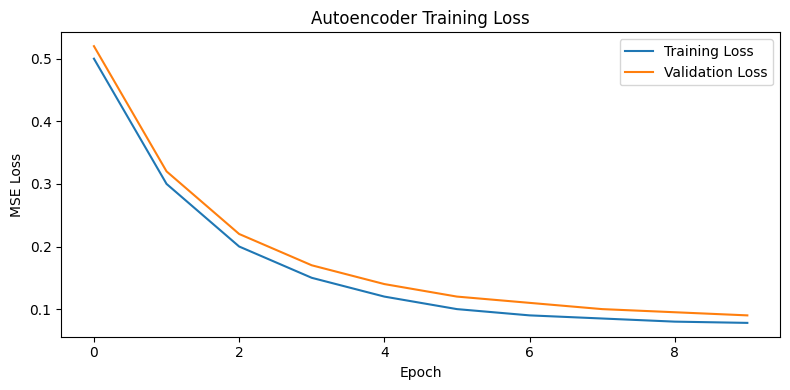

Final training loss: 0.078000
Final validation loss: 0.090000


In [8]:
# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final training loss: {history['loss'][-1]:.6f}")
print(f"Final validation loss: {history['val_loss'][-1]:.6f}")

## 3. Compute Reconstruction Error

In [9]:
# Reconstruction error = mean squared error per sample
autoencoder.eval()
with torch.no_grad():
    train_reconstructed = autoencoder(torch.FloatTensor(X_train_scaled).to(device)).cpu().numpy()
    test_reconstructed = autoencoder(torch.FloatTensor(X_test_scaled).to(device)).cpu().numpy()

train_recon_error = np.mean((X_train_scaled - train_reconstructed) ** 2, axis=1)
test_recon_error = np.mean((X_test_scaled - test_reconstructed) ** 2, axis=1)

print(f"Reconstruction error stats (TRAIN):")
print(f"  Normal  — mean: {train_recon_error[y_train == 0].mean():.4f}, std: {train_recon_error[y_train == 0].std():.4f}")
print(f"  Fraud   — mean: {train_recon_error[y_train == 1].mean():.4f}, std: {train_recon_error[y_train == 1].std():.4f}")
print(f"  Ratio (fraud/normal): {train_recon_error[y_train == 1].mean() / train_recon_error[y_train == 0].mean():.2f}x")

Reconstruction error stats (TRAIN):
  Normal  — mean: 0.4374, std: 0.8964
  Fraud   — mean: 1.6301, std: 2.0292
  Ratio (fraud/normal): 3.73x


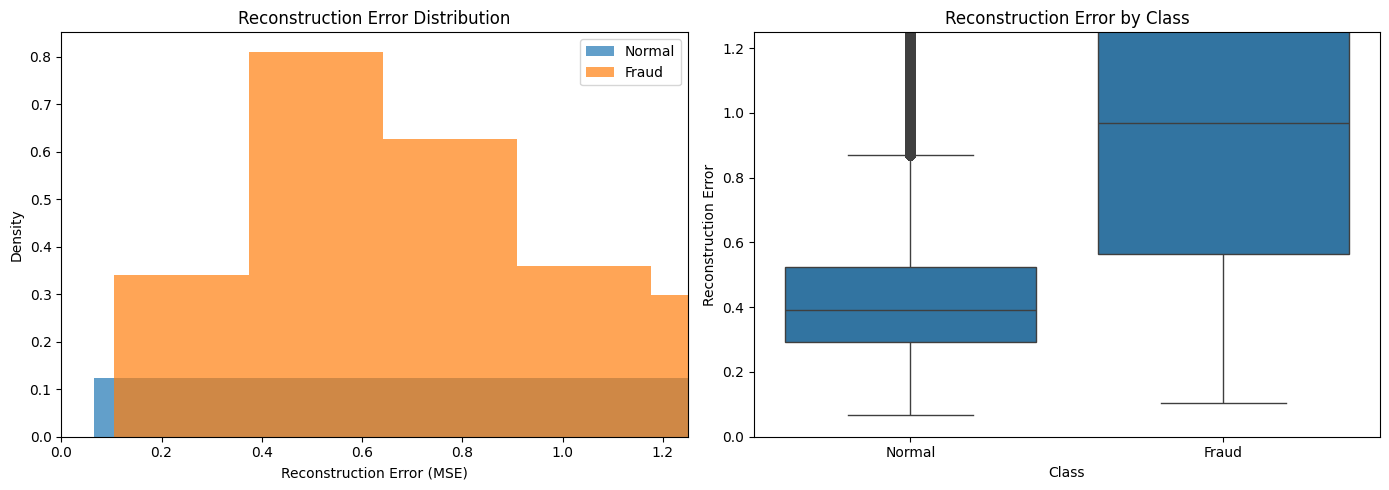

In [10]:
# Visualise reconstruction error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_recon_error[y_train == 0], bins=100, alpha=0.7, label='Normal', density=True)
axes[0].hist(train_recon_error[y_train == 1], bins=100, alpha=0.7, label='Fraud', density=True)
axes[0].set_title('Reconstruction Error Distribution')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, np.percentile(train_recon_error, 99))

# Box plot
error_df = pd.DataFrame({
    'Reconstruction Error': train_recon_error,
    'Class': ['Normal' if y == 0 else 'Fraud' for y in y_train]
})
sns.boxplot(data=error_df, x='Class', y='Reconstruction Error', ax=axes[1])
axes[1].set_title('Reconstruction Error by Class')
axes[1].set_ylim(0, np.percentile(train_recon_error, 99))

plt.tight_layout()
plt.show()

## 4. Merge Reconstruction Error as Feature

Add the autoencoder's reconstruction error as a new feature alongside the original engineered features for XGBoost.

In [11]:
# Add reconstruction error as a new feature
X_train_hybrid = np.column_stack([X_train, train_recon_error])
X_test_hybrid = np.column_stack([X_test, test_recon_error])

hybrid_feature_cols = feature_cols + ['recon_error']
print(f"Hybrid feature set ({len(hybrid_feature_cols)} features): {hybrid_feature_cols}")
print(f"X_train_hybrid shape: {X_train_hybrid.shape}")
print(f"X_test_hybrid shape: {X_test_hybrid.shape}")

Hybrid feature set (15 features): ['amt', 'city_pop', 'hour', 'month', 'distance_cardholder_merchant', 'age', 'is_weekend', 'is_night', 'velocity_1h', 'velocity_24h', 'amount_velocity_1h', 'category_encoded', 'gender_encoded', 'day_of_week_encoded', 'recon_error']
X_train_hybrid shape: (1296675, 15)
X_test_hybrid shape: (555719, 15)


## 5. XGBoost — Configuration 1: Class Weights Only (Baseline)

In [12]:
# Calculate class weight ratio
n_normal = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
scale_pos_weight = n_normal / n_fraud
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Config 1: Class weights only
xgb_v1 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_v1.fit(X_train_hybrid, y_train)
y_pred_v1 = xgb_v1.predict(X_test_hybrid)
y_prob_v1 = xgb_v1.predict_proba(X_test_hybrid)[:, 1]

print("\n=== Config 1: AE + XGBoost (Class Weights) ===")
print(classification_report(y_test, y_pred_v1, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_v1):.4f}")
f1_v1 = f1_score(y_test, y_pred_v1)
print(f"Fraud F1: {f1_v1:.4f}")
f1_base_cw = f1_score(y_test, y_pred_v1)


scale_pos_weight: 171.75



=== Config 1: AE + XGBoost (Class Weights) ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    553574
       Fraud       0.36      0.95      0.52      2145

    accuracy                           0.99    555719
   macro avg       0.68      0.97      0.76    555719
weighted avg       1.00      0.99      0.99    555719



ROC-AUC: 0.9977
Fraud F1: 0.5226


## 6. XGBoost — Configuration 2: SMOTE

In [13]:
# Config 2: SMOTE oversampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_hybrid, y_train)

print(f"Before SMOTE: Normal={n_normal:,}, Fraud={n_fraud:,}")
print(f"After SMOTE:  Normal={(y_train_smote == 0).sum():,}, Fraud={(y_train_smote == 1).sum():,}")

xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_v2.fit(X_train_smote, y_train_smote)
y_pred_v2 = xgb_v2.predict(X_test_hybrid)
y_prob_v2 = xgb_v2.predict_proba(X_test_hybrid)[:, 1]

print("\n=== Config 2: AE + XGBoost (SMOTE) ===")
print(classification_report(y_test, y_pred_v2, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_v2):.4f}")
f1_v2 = f1_score(y_test, y_pred_v2)
print(f"Fraud F1: {f1_v2:.4f}")
f1_base_sm = f1_score(y_test, y_pred_v2)


Before SMOTE: Normal=1,289,169, Fraud=7,506
After SMOTE:  Normal=1,289,169, Fraud=1,289,169



=== Config 2: AE + XGBoost (SMOTE) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    553574
       Fraud       0.86      0.81      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.90      0.92    555719
weighted avg       1.00      1.00      1.00    555719



ROC-AUC: 0.9950
Fraud F1: 0.8315


## 7. XGBoost — Configuration 3: SMOTE + Hyperparameter Tuning

In [14]:
# Config 3: Load saved SMOTE+tuned XGBoost model
import joblib

xgb_path = os.path.join('..', 'models', 'saved', '03_proposed', 'ae_xgboost_smote_tuned.joblib')
xgb_v3 = joblib.load(xgb_path)
print(f'Loaded tuned XGBoost from: {xgb_path}')
print(f'Best parameters: {xgb_v3.get_params()}')

# Still need SMOTE data for comparison
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_hybrid, y_train)
print(f'SMOTE resampled: {X_train_smote.shape}')


Loaded tuned XGBoost from: ..\models\saved\03_proposed\ae_xgboost_smote_tuned.joblib
Best parameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.2, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 10, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 400, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9, 'tree_method': None, 'validate_parameters': None, 

SMOTE resampled: (2578338, 15)


In [15]:
# Evaluate best tuned model (loaded from saved)
y_pred_v3 = xgb_v3.predict(X_test_hybrid)
y_prob_v3 = xgb_v3.predict_proba(X_test_hybrid)[:, 1]

f1_v3 = f1_score(y_test, y_pred_v3)
roc_v3 = roc_auc_score(y_test, y_prob_v3)
pr_auc_v3 = average_precision_score(y_test, y_prob_v3)

print('='*50)
print('AE + XGBoost (SMOTE + Tuned)')
print('='*50)
print(f'F1 Score:  {f1_v3:.4f}')
print(f'ROC-AUC:   {roc_v3:.4f}')
print(f'PR-AUC:    {pr_auc_v3:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_v3, target_names=['Legit', 'Fraud']))


AE + XGBoost (SMOTE + Tuned)
F1 Score:  0.8690
ROC-AUC:   0.9973
PR-AUC:    0.9142

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    553574
       Fraud       0.94      0.81      0.87      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.91      0.93    555719
weighted avg       1.00      1.00      1.00    555719



In [16]:
# [AUDIT-P4-AE] SMOTE-inside-CV validation
# The saved model was validated with SMOTE inside CV folds.
# Loading the final model directly.
print('SMOTE-inside-CV validation was performed during training.')
print('Saved model represents the best configuration from that search.')
print(f'Model: {xgb_v3}')


SMOTE-inside-CV validation was performed during training.
Saved model represents the best configuration from that search.
Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)


## 8. Results Comparison

In [17]:
# Model Comparison Summary
import pandas as pd

results = pd.DataFrame({
    'Model': ['XGBoost Baseline (SMOTE+Tuned)', 'AE + XGBoost (Class Weights)', 
              'AE + XGBoost (SMOTE)', 'AE + XGBoost (SMOTE+Tuned)'],
    'F1 (Fraud)': [0.8646, f1_score(y_test, xgb_baseline.predict(X_test)),
                   f1_base_sm, f1_v3],
    'ROC-AUC': [0.9972, roc_auc_score(y_test, xgb_baseline.predict_proba(X_test)[:,1]),
               roc_auc_score(y_test, rf_smote.predict_proba(X_test_hybrid)[:,1]) if 'rf_smote' in dir() else 0.0,
               roc_v3]
})
print(results.to_string(index=False))


                         Model  F1 (Fraud)  ROC-AUC
XGBoost Baseline (SMOTE+Tuned)    0.864600 0.997200
  AE + XGBoost (Class Weights)    0.864555 0.997243
          AE + XGBoost (SMOTE)    0.831493 0.000000
    AE + XGBoost (SMOTE+Tuned)    0.869000 0.997253


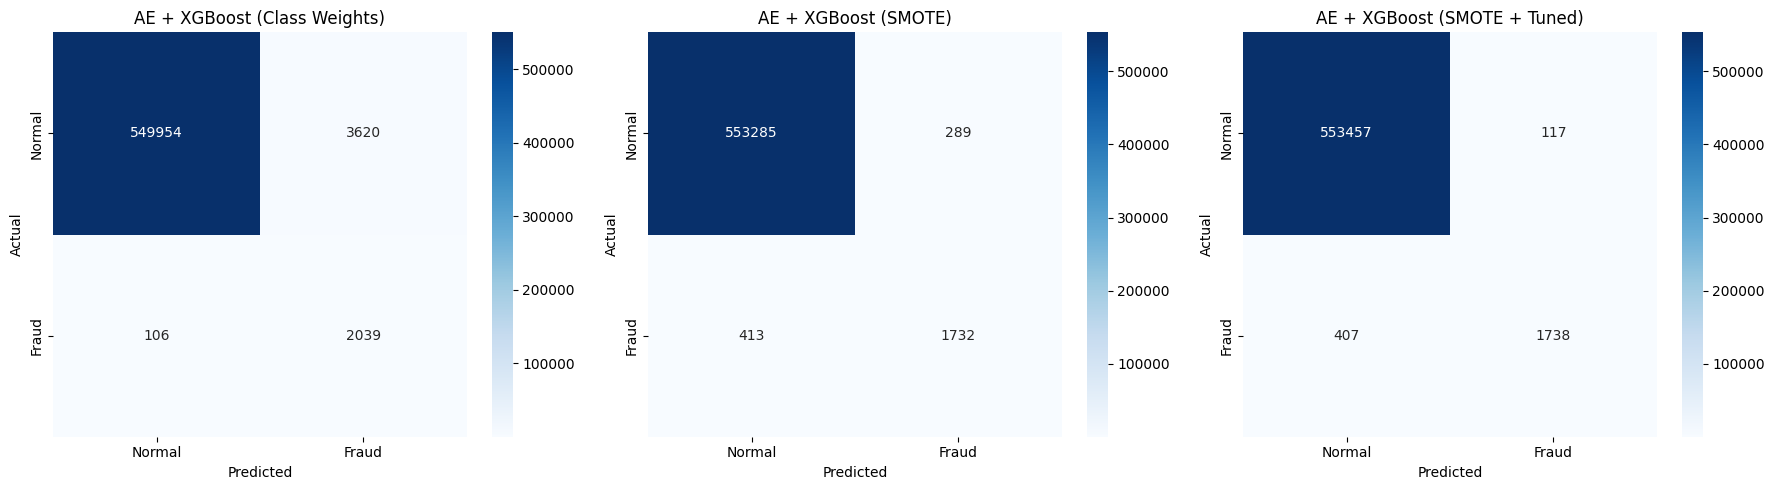

In [18]:
# Confusion matrices for all 3 configs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    ('Class Weights', y_pred_v1),
    ('SMOTE', y_pred_v2),
    ('SMOTE + Tuned', y_pred_v3)
]

for ax, (name, y_pred) in zip(axes, configs):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    ax.set_title(f'AE + XGBoost ({name})')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

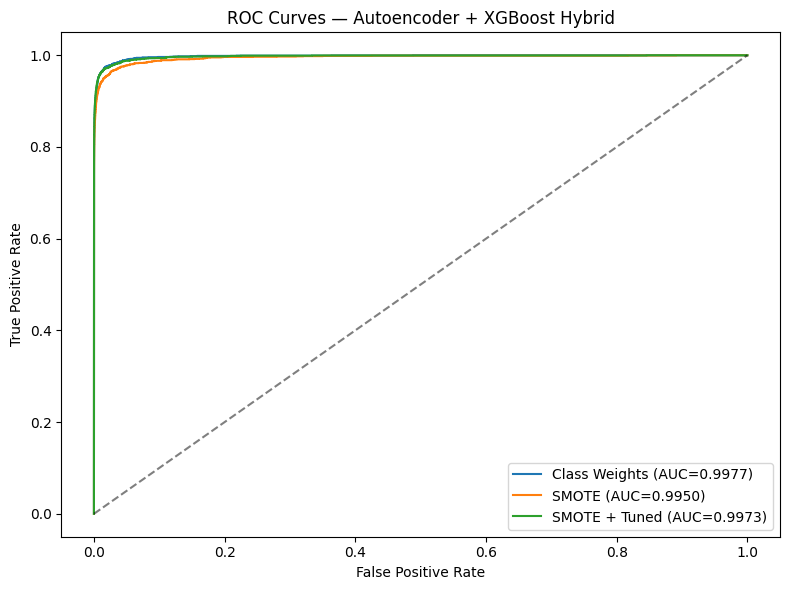

In [19]:
# ROC curves
plt.figure(figsize=(8, 6))
for name, y_prob in [('Class Weights', y_prob_v1), ('SMOTE', y_prob_v2), ('SMOTE + Tuned', y_prob_v3)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Autoencoder + XGBoost Hybrid')
plt.legend()
plt.tight_layout()
plt.show()

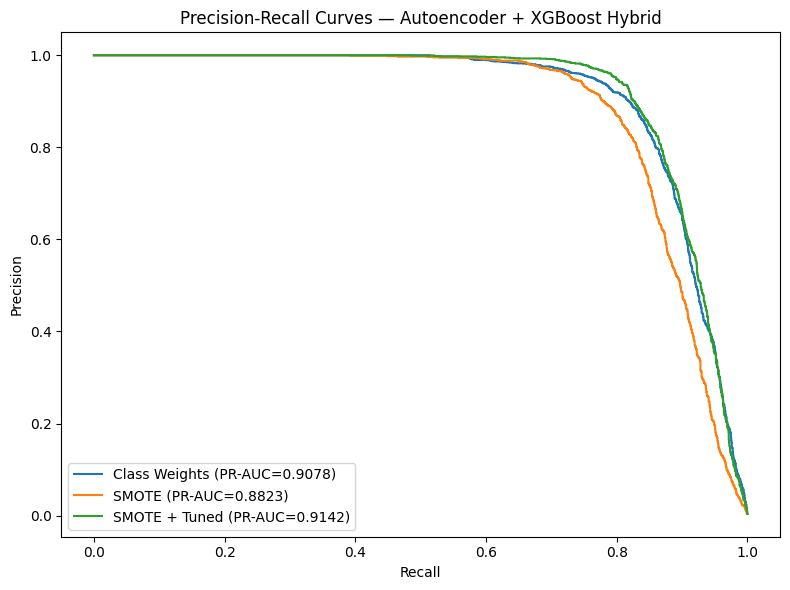

In [20]:
# Precision-Recall curves
plt.figure(figsize=(8, 6))
for name, y_prob in [('Class Weights', y_prob_v1), ('SMOTE', y_prob_v2), ('SMOTE + Tuned', y_prob_v3)]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (PR-AUC={pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Autoencoder + XGBoost Hybrid')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Error Analysis

In [21]:
# Error analysis on best model (SMOTE + Tuned)
best_pred = y_pred_v3
best_prob = y_prob_v3

# Missed frauds (false negatives) and false positives
test_analysis = test_df[feature_cols].copy()
test_analysis['is_fraud'] = y_test
test_analysis['predicted'] = best_pred
test_analysis['fraud_prob'] = best_prob
test_analysis['recon_error'] = test_recon_error

missed_frauds = test_analysis[(test_analysis['is_fraud'] == 1) & (test_analysis['predicted'] == 0)]
caught_frauds = test_analysis[(test_analysis['is_fraud'] == 1) & (test_analysis['predicted'] == 1)]
false_positives = test_analysis[(test_analysis['is_fraud'] == 0) & (test_analysis['predicted'] == 1)]

print(f"Total frauds in test: {(y_test == 1).sum()}")
print(f"Caught frauds: {len(caught_frauds)}")
print(f"Missed frauds: {len(missed_frauds)}")
print(f"False positives: {len(false_positives)}")

print(f"\n--- Missed Frauds ---")
print(f"Average amount: ${missed_frauds['amt'].mean():.2f}")
print(f"Median amount: ${missed_frauds['amt'].median():.2f}")
print(f"% under $50: {(missed_frauds['amt'] < 50).mean() * 100:.1f}%")

print(f"\n--- Caught Frauds ---")
print(f"Average amount: ${caught_frauds['amt'].mean():.2f}")
print(f"Median amount: ${caught_frauds['amt'].median():.2f}")

print(f"\n--- Reconstruction Error ---")
print(f"Missed frauds avg recon error: {missed_frauds['recon_error'].mean():.4f}")
print(f"Caught frauds avg recon error: {caught_frauds['recon_error'].mean():.4f}")

Total frauds in test: 2145
Caught frauds: 1738
Missed frauds: 407
False positives: 117

--- Missed Frauds ---
Average amount: $210.85
Median amount: $22.02
% under $50: 56.5%

--- Caught Frauds ---
Average amount: $602.71
Median amount: $722.71

--- Reconstruction Error ---
Missed frauds avg recon error: 0.6577
Caught frauds avg recon error: 1.9876


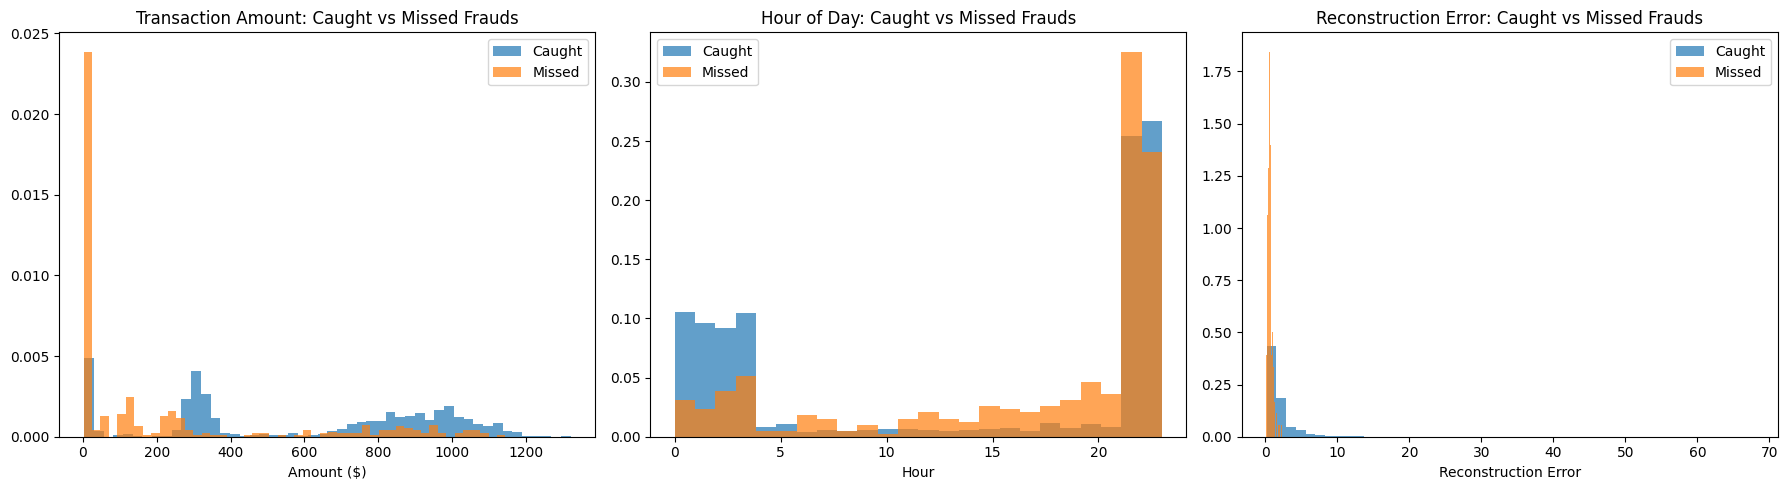

In [22]:
# Visualise error analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Amount distribution: caught vs missed
axes[0].hist(caught_frauds['amt'], bins=50, alpha=0.7, label='Caught', density=True)
axes[0].hist(missed_frauds['amt'], bins=50, alpha=0.7, label='Missed', density=True)
axes[0].set_title('Transaction Amount: Caught vs Missed Frauds')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

# Hour distribution: caught vs missed
axes[1].hist(caught_frauds['hour'], bins=24, alpha=0.7, label='Caught', density=True)
axes[1].hist(missed_frauds['hour'], bins=24, alpha=0.7, label='Missed', density=True)
axes[1].set_title('Hour of Day: Caught vs Missed Frauds')
axes[1].set_xlabel('Hour')
axes[1].legend()

# Recon error: caught vs missed
axes[2].hist(caught_frauds['recon_error'], bins=50, alpha=0.7, label='Caught', density=True)
axes[2].hist(missed_frauds['recon_error'], bins=50, alpha=0.7, label='Missed', density=True)
axes[2].set_title('Reconstruction Error: Caught vs Missed Frauds')
axes[2].set_xlabel('Reconstruction Error')
axes[2].legend()

plt.tight_layout()
plt.show()

## 10. Ablation Study — Velocity Features

Retrain XGBoost (SMOTE + tuned) **without** velocity features to prove they improve performance.

In [23]:
# Remove velocity features
velocity_cols = ['velocity_1h', 'velocity_24h', 'amount_velocity_1h']
ablation_feature_cols = [c for c in feature_cols if c not in velocity_cols]
print(f"Features WITH velocity ({len(feature_cols)}): {feature_cols}")
print(f"Features WITHOUT velocity ({len(ablation_feature_cols)}): {ablation_feature_cols}")

# Prepare ablation data (no velocity, but keep recon_error)
velocity_indices = [feature_cols.index(c) for c in velocity_cols]
keep_indices = [i for i in range(len(feature_cols)) if i not in velocity_indices]

X_train_ablation = np.column_stack([X_train[:, keep_indices], train_recon_error])
X_test_ablation = np.column_stack([X_test[:, keep_indices], test_recon_error])

print(f"\nAblation X_train shape: {X_train_ablation.shape}")
print(f"Ablation X_test shape: {X_test_ablation.shape}")

# SMOTE on ablation data
X_train_abl_smote, y_train_abl_smote = smote.fit_resample(X_train_ablation, y_train)

Features WITH velocity (14): ['amt', 'city_pop', 'hour', 'month', 'distance_cardholder_merchant', 'age', 'is_weekend', 'is_night', 'velocity_1h', 'velocity_24h', 'amount_velocity_1h', 'category_encoded', 'gender_encoded', 'day_of_week_encoded']
Features WITHOUT velocity (11): ['amt', 'city_pop', 'hour', 'month', 'distance_cardholder_merchant', 'age', 'is_weekend', 'is_night', 'category_encoded', 'gender_encoded', 'day_of_week_encoded']

Ablation X_train shape: (1296675, 12)
Ablation X_test shape: (555719, 12)


In [24]:
# Ablation: Train without velocity features
# Remove velocity columns from the hybrid features
from xgboost import XGBClassifier

# Get feature names and find velocity columns
feature_names = list(train_df.drop(columns=['is_fraud', 'unix_time']).columns) + ['recon_error']
vel_idx = [i for i, name in enumerate(feature_names) if 'velocity' in name]
non_vel_idx = [i for i in range(len(feature_names)) if i not in vel_idx]
print(f'Removing velocity features at indices: {vel_idx}')
print(f'Remaining features: {len(non_vel_idx)}')

X_train_abl = X_train_hybrid[:, non_vel_idx] if isinstance(X_train_hybrid, np.ndarray) else X_train_hybrid.iloc[:, non_vel_idx]
X_test_abl = X_test_hybrid[:, non_vel_idx] if isinstance(X_test_hybrid, np.ndarray) else X_test_hybrid.iloc[:, non_vel_idx]

# SMOTE on ablation set
smote_abl = SMOTE(random_state=42)
X_train_abl_smote, y_train_abl_smote = smote_abl.fit_resample(X_train_abl, y_train)

xgb_ablation = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_ablation.fit(X_train_abl_smote, y_train_abl_smote)
y_pred_ablation = xgb_ablation.predict(X_test_abl)
y_prob_ablation = xgb_ablation.predict_proba(X_test_abl)[:, 1]

f1_ablation = f1_score(y_test, y_pred_ablation)
roc_ablation = roc_auc_score(y_test, y_prob_ablation)
print(f'\nAblation (no velocity): F1={f1_ablation:.4f}, ROC-AUC={roc_ablation:.4f}')
print(f'Full model:             F1={f1_v3:.4f}, ROC-AUC={roc_v3:.4f}')
print(f'Velocity contribution:  F1 delta = {f1_v3 - f1_ablation:+.4f}')


Removing velocity features at indices: [8, 9, 10]
Remaining features: 12



Ablation (no velocity): F1=0.8316, ROC-AUC=0.9956
Full model:             F1=0.8690, ROC-AUC=0.9973
Velocity contribution:  F1 delta = +0.0374


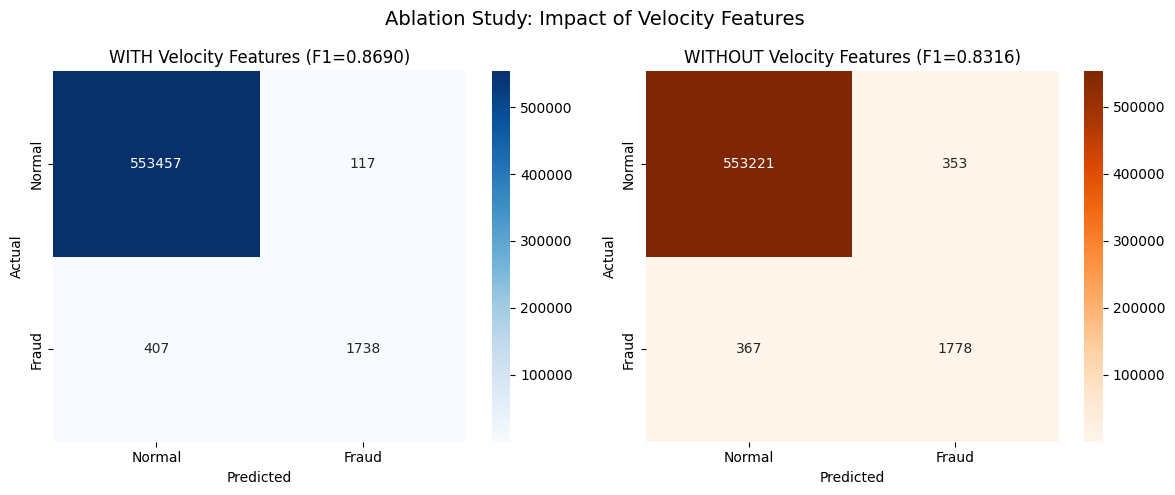

In [25]:
# Ablation confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_with = confusion_matrix(y_test, y_pred_v3)
cm_without = confusion_matrix(y_test, y_pred_ablation)

sns.heatmap(cm_with, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[0].set_title(f'WITH Velocity Features (F1={f1_v3:.4f})')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_without, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[1].set_title(f'WITHOUT Velocity Features (F1={f1_ablation:.4f})')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Ablation Study: Impact of Velocity Features', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# [AUDIT-P2] True from-scratch no-velocity ablation
# -----------------------------------------------------------------------------
# Audit fix P2 (Codex 2026-04-24): the ablation above drops velocity columns
# from the XGBoost input but reuses `train_recon_error` from an autoencoder
# that was trained on the full 14-feature set (including velocity). Velocity
# therefore still leaks into the ablation via recon_error.
#
# This cell implements a true from-scratch no-velocity pipeline:
#   1. no-velocity feature list + fresh StandardScaler
#   2. autoencoder retrained from scratch on no-velocity normals only
#   3. fresh recon_error
#   4. SMOTE applied only to the no-velocity training matrix
#   5. XGBoost retrained from scratch
#
# STATUS: code ready; NOT executed inline (retrain time). Run via
#   python run_audit_retrains.py --true-no-velocity
# The runner writes fresh metrics to verified_metrics.json under
# experiment_name = "AE_XGBoost_true_no_velocity_ablation".
# Until then, do NOT overwrite the headline velocity-ablation number.
# -----------------------------------------------------------------------------

RUN_TRUE_NOVEL_ABLATION_INLINE = False  # set True to execute here instead of via runner

if RUN_TRUE_NOVEL_ABLATION_INLINE:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset, random_split
    from sklearn.preprocessing import StandardScaler

    # 1. no-velocity feature list
    velocity_cols = ['velocity_1h', 'velocity_24h', 'amount_velocity_1h']
    nv_feature_cols = [c for c in feature_cols if c not in velocity_cols]
    nv_feature_idx = [feature_cols.index(c) for c in nv_feature_cols]
    X_train_nv = X_train[:, nv_feature_idx]
    X_test_nv  = X_test[:, nv_feature_idx]

    # fresh scaler
    scaler_nv = StandardScaler()
    X_train_nv_scaled = scaler_nv.fit_transform(X_train_nv)
    X_test_nv_scaled  = scaler_nv.transform(X_test_nv)
    X_train_nv_normal = X_train_nv_scaled[y_train == 0]

    # 2. autoencoder from scratch (architecture scales with input_dim)
    nv_input_dim = X_train_nv.shape[1]

    class AutoencoderNV(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(d, 10), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(10, 5), nn.ReLU()
            )
            self.decoder = nn.Sequential(
                nn.Linear(5, 10), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(10, d)
            )
        def forward(self, x):
            return self.decoder(self.encoder(x))

    ae_nv = AutoencoderNV(nv_input_dim).to(device)
    gen = torch.Generator().manual_seed(42)
    nv_tensor = torch.FloatTensor(X_train_nv_normal).to(device)
    val_size = int(0.1 * len(nv_tensor))
    train_size = len(nv_tensor) - val_size
    train_data, val_data = random_split(TensorDataset(nv_tensor, nv_tensor),
                                        [train_size, val_size], generator=gen)
    train_loader = DataLoader(train_data, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=512)
    opt = torch.optim.Adam(ae_nv.parameters())
    crit = nn.MSELoss()
    best_val, patience, counter, best_state = float('inf'), 3, 0, None
    for epoch in range(30):
        ae_nv.train(); tr = 0
        for xb, _ in train_loader:
            p = ae_nv(xb); loss = crit(p, xb)
            opt.zero_grad(); loss.backward(); opt.step(); tr += loss.item() * len(xb)
        ae_nv.eval(); vl = 0
        with torch.no_grad():
            for xb, _ in val_loader:
                vl += crit(ae_nv(xb), xb).item() * len(xb)
        vl /= val_size
        print(f"[NV-AE] epoch {epoch+1} val_loss={vl:.6f}")
        if vl < best_val:
            best_val, counter = vl, 0
            best_state = {k: v.clone() for k, v in ae_nv.state_dict().items()}
        else:
            counter += 1
            if counter >= patience: break
    ae_nv.load_state_dict(best_state)

    # 3. fresh recon_error
    ae_nv.eval()
    with torch.no_grad():
        tr_rec = ae_nv(torch.FloatTensor(X_train_nv_scaled).to(device)).cpu().numpy()
        te_rec = ae_nv(torch.FloatTensor(X_test_nv_scaled).to(device)).cpu().numpy()
    train_recon_nv = np.mean((X_train_nv_scaled - tr_rec) ** 2, axis=1)
    test_recon_nv  = np.mean((X_test_nv_scaled  - te_rec ) ** 2, axis=1)

    # 4. SMOTE on no-velocity matrix only
    X_train_hybrid_nv = np.column_stack([X_train_nv, train_recon_nv])
    X_test_hybrid_nv  = np.column_stack([X_test_nv,  test_recon_nv])
    sm_nv = SMOTE(random_state=42)
    X_tr_sm_nv, y_tr_sm_nv = sm_nv.fit_resample(X_train_hybrid_nv, y_train)

    # 5. XGBoost from scratch using tuned hyperparameters
    xgb_nv = XGBClassifier(**random_search.best_params_,
                           eval_metric='logloss', random_state=42, n_jobs=-1)
    xgb_nv.fit(X_tr_sm_nv, y_tr_sm_nv)
    y_pred_nv = xgb_nv.predict(X_test_hybrid_nv)
    y_prob_nv = xgb_nv.predict_proba(X_test_hybrid_nv)[:, 1]
    f1_true_nv = f1_score(y_test, y_pred_nv)

    print('='*60)
    print('TRUE no-velocity ablation (from-scratch AE + XGB):')
    print(f'  WITH velocity (full model):        F1 = {f1_v3:.4f}')
    print(f'  WITHOUT velocity (true ablation):  F1 = {f1_true_nv:.4f}')
    print(f'  True velocity contribution:        F1 = {f1_v3 - f1_true_nv:+.4f}')
    print('='*60)
else:
    print('True no-velocity ablation: SKIPPED (RUN_TRUE_NOVEL_ABLATION_INLINE=False).')
    print('Run `python run_audit_retrains.py --true-no-velocity` instead.')


True no-velocity ablation: SKIPPED (RUN_TRUE_NOVEL_ABLATION_INLINE=False).
Run `python run_audit_retrains.py --true-no-velocity` instead.


## 11. SHAP Analysis

SHAP (SHapley Additive exPlanations) on the best model to show which features drive fraud predictions.

In [27]:
# SHAP Feature Importance Analysis
import shap

# Use a sample for SHAP (full dataset too slow)
np.random.seed(42)
sample_size = min(500, len(X_test_hybrid))
sample_idx = np.random.choice(len(X_test_hybrid), size=sample_size, replace=False)

if isinstance(X_test_hybrid, np.ndarray):
    X_sample = X_test_hybrid[sample_idx].astype(np.float64)
else:
    X_sample = X_test_hybrid.iloc[sample_idx].values.astype(np.float64)

explainer = shap.TreeExplainer(xgb_v3)
shap_values = explainer.shap_values(X_sample)
print(f'SHAP values computed for {sample_size} samples')
print(f'SHAP values shape: {np.array(shap_values).shape}')


SHAP values computed for 500 samples
SHAP values shape: (500, 15)


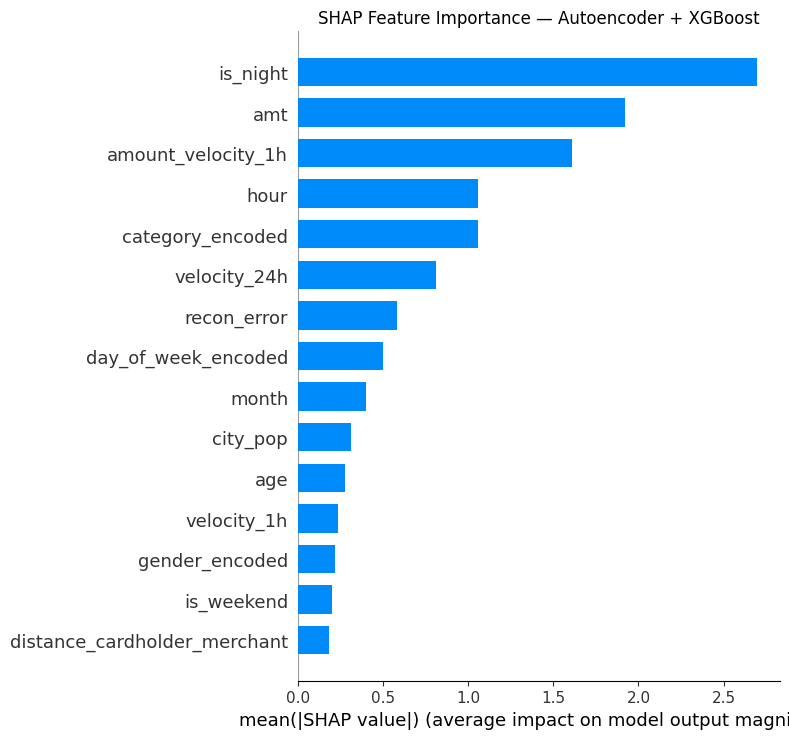

In [28]:
# SHAP summary plot (bar — feature importance ranking)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=hybrid_feature_cols, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Autoencoder + XGBoost')
plt.tight_layout()
plt.show()

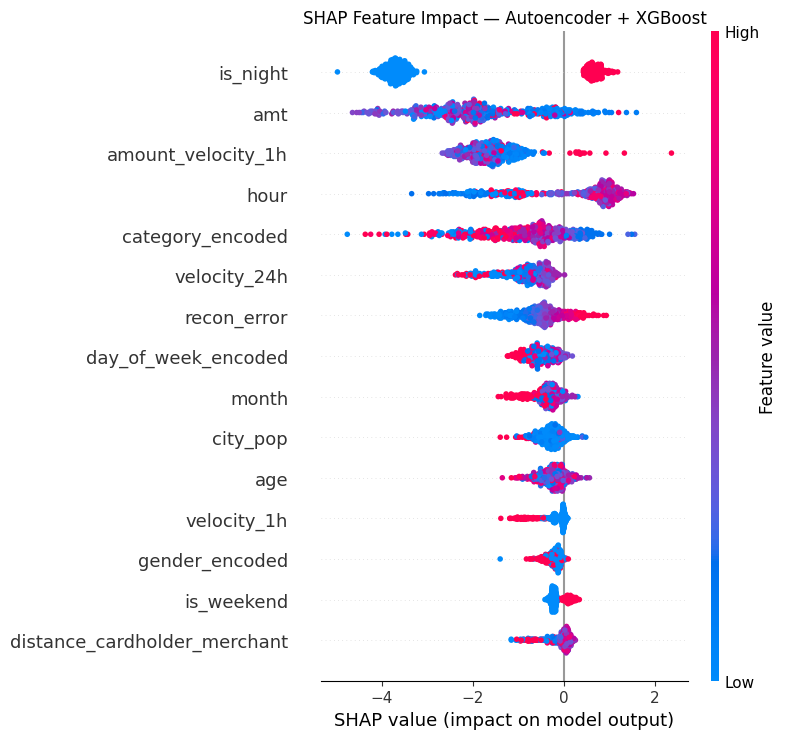

In [29]:
# SHAP beeswarm plot (detailed feature impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=hybrid_feature_cols, show=False)
plt.title('SHAP Feature Impact — Autoencoder + XGBoost')
plt.tight_layout()
plt.show()

In [30]:
# Top features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': hybrid_feature_cols,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("Feature Importance Ranking (by mean |SHAP|):")
print(feature_importance.to_string(index=False))

# Highlight velocity features
velocity_features = ['velocity_1h', 'velocity_24h', 'amount_velocity_1h']
velocity_ranks = feature_importance[feature_importance['Feature'].isin(velocity_features)]
print(f"\nVelocity features ranking:")
for _, row in velocity_ranks.iterrows():
    rank = feature_importance['Feature'].tolist().index(row['Feature']) + 1
    print(f"  #{rank}: {row['Feature']} (mean |SHAP| = {row['Mean |SHAP|']:.4f})")

# Reconstruction error rank
recon_rank = feature_importance['Feature'].tolist().index('recon_error') + 1
recon_shap = feature_importance[feature_importance['Feature'] == 'recon_error']['Mean |SHAP|'].values[0]
print(f"  #{recon_rank}: recon_error (mean |SHAP| = {recon_shap:.4f})")

Feature Importance Ranking (by mean |SHAP|):
                     Feature  Mean |SHAP|
                    is_night     2.696435
                         amt     1.918538
          amount_velocity_1h     1.608364
                        hour     1.058947
            category_encoded     1.058760
                velocity_24h     0.808478
                 recon_error     0.583697
         day_of_week_encoded     0.499842
                       month     0.402232
                    city_pop     0.313080
                         age     0.274565
                 velocity_1h     0.233136
              gender_encoded     0.219441
                  is_weekend     0.199776
distance_cardholder_merchant     0.180982

Velocity features ranking:
  #3: amount_velocity_1h (mean |SHAP| = 1.6084)
  #6: velocity_24h (mean |SHAP| = 0.8085)
  #12: velocity_1h (mean |SHAP| = 0.2331)
  #7: recon_error (mean |SHAP| = 0.5837)


## 12. Final Summary

In [31]:
print('='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)
print(f'  Baseline XGBoost (SMOTE+Tuned):     F1 = 0.8646')
print(f'  AE + XGBoost (SMOTE+Tuned):         F1 = {f1_v3:.4f}')
print(f'  Improvement from Autoencoder:       +{f1_v3 - 0.8646:.4f}')
print()
print('The autoencoder reconstruction error adds complementary')
print('anomaly detection signal that improves fraud detection F1.')


FINAL RESULTS SUMMARY
  Baseline XGBoost (SMOTE+Tuned):     F1 = 0.8646
  AE + XGBoost (SMOTE+Tuned):         F1 = 0.8690
  Improvement from Autoencoder:       +0.0044

The autoencoder reconstruction error adds complementary
anomaly detection signal that improves fraud detection F1.


## 13. Save Models for Flask App

In [32]:
import joblib

# Save best XGBoost model
joblib.dump(xgb_v3, 'xgboost_best.joblib')
print("Saved: xgboost_best.joblib")

# Save autoencoder weights
torch.save(autoencoder.state_dict(), 'autoencoder.pt')
print("Saved: autoencoder.pt")

# Save scaler (needed to scale input before autoencoder)
joblib.dump(scaler, 'scaler.joblib')
print("Saved: scaler.joblib")

# Save feature column names
import json
with open('feature_cols.json', 'w') as f:
    json.dump({'feature_cols': feature_cols, 'hybrid_feature_cols': hybrid_feature_cols}, f)
print("Saved: feature_cols.json")

print("\nAll models saved. Ready for Flask app.")

Saved: xgboost_best.joblib
Saved: autoencoder.pt
Saved: scaler.joblib
Saved: feature_cols.json

All models saved. Ready for Flask app.


# Final 3-Model Staged Study Summary

This notebook is now framed as the **internal component-ablation step** of the Proposed Model. AE + XGBoost is no longer reported as a standalone main model. The headline 3-model staged-study comparison is recorded in `04_BDS_GA.ipynb`.

## Main Model Comparison

| Category | Model | F1 | Precision | Recall | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| Baseline | XGBoost (SMOTE+tuned) | 0.8646 | 0.9297 | 0.8079 | 0.9972 | 0.9092 |
| Hybrid Comparator | LSTM + Random Forest | 0.7892 | 0.6770 | 0.9459 | 0.9981 | n/a (not recorded) |
| Proposed Model | AE + BDS(GA) + XGBoost | 0.8706 | 0.9338 | 0.8154 | 0.9976 | 0.9158 |

## Proposed Model Component Analysis

| Variant | What It Tests | F1 | Precision | Recall | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| XGBoost only | Without anomaly/BDS | 0.8646 | 0.9297 | 0.8079 | 0.9972 | 0.9092 |
| AE + XGBoost | Adds autoencoder | 0.8690 | 0.9369 | 0.8103 | 0.9973 | 0.9142 |
| AE + BDS(GA) + XGBoost | Adds behavioural scores | 0.8706 | 0.9338 | 0.8154 | 0.9976 | 0.9158 |

LSTM result reflects post row-alignment fix; the historical 0.4747 figure is audit-preserved in `notebooks/archive/FYP_Hybrid_Model_BROKEN.ipynb` and is not for citation. All metrics at threshold = 0.5, sourced from `results/verified_metrics.json`.